# 02 — Data Preprocessing and Label Construction

**Project:** MeetingMind | **Phase:** 3

## Goal
Turn AMI annotations into a supervised dataset for a **decision / action utterance detector**.

## How labels are derived (verified from the raw XML in notebook 01)
- `abstractive/<meeting>.abssumm.xml`: summary sentences grouped under `abstract`, `actions`, `decisions`, `problems`
- `extractive/<meeting>.summlink.xml`: links a **dialogue act** (extractive) to an **abstractive sentence**
- So: dialogue act linked to a sentence under `actions` -> **action**, under `decisions` -> **decision**, etc.

## Known label-quality limits (read before trusting any metric)
1. Only dialogue acts chosen for the extractive summary are linked. A real decision utterance that annotators skipped is labelled `other`. Labels are **incomplete**, so recall will be underestimated.
2. A dialogue act can link to several sentence types. We resolve with priority action > decision > problem > other and report how many rows are affected.
3. Meetings without summary links are **excluded**, not labelled all-`other`.
4. `da_type` is kept for analysis only. It must **not** be a model feature, because our real pipeline has no dialogue-act tags.

## Split policy
Split by **session** (first 6 characters of the meeting ID, e.g. `ES2002`). Meetings a-d of a session share participants and topic, so splitting by meeting or utterance would leak.

## 1. Imports and configuration

In [1]:
import re
import collections
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ami"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ANN_ROOT = next(p.parent for p in RAW_DIR.rglob("words") if p.is_dir())

RANDOM_SEED = 42
SPLIT_FRACTIONS = {"train": 0.70, "val": 0.15, "test": 0.15}  # fractions of SESSIONS
LABEL_PRIORITY = ["action", "decision", "problem"]           # first match wins; otherwise 'other'

print("Annotation root:", ANN_ROOT)

Annotation root: c:\Users\Harijith\Downloads\data\raw\ami


## 2. Load the utterance table from notebook 01

In [2]:
utterances = pd.read_csv(PROCESSED_DIR / "ami_utterances_raw.csv")
utterances["text"] = utterances["text"].fillna("").astype(str)
print(utterances.shape)
print("Meetings:", utterances["meeting_id"].nunique())
utterances.head(3)

(110795, 9)
Meetings: 139


,meeting_id,speaker,dact_id,start,end,text,da_type_id,da_type,n_words
0,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.1,50.420,50.99,Okay,ami_da_2,Stall,1
1,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.2,53.560,53.96,Right,ami_da_2,Stall,1
2,ES2002a,ES2002a_B,ES2002a.B.dialog-act.dharshi.3,55.415,60.35,Um well this is the kick-off meeting for our o...,ami_da_4,Inform,11


## 3. Leftover folders
`decision/` and `argumentation/` printed "no files" in notebook 01. Confirm they are really empty of data files.

In [3]:
for name in ["decision", "argumentation"]:
    folder = ANN_ROOT / name
    files = [f for f in folder.rglob("*") if f.is_file()]
    print(f"{name}: {len(files)} files", [f.name for f in files[:5]])

decision: 47 files ['ES2002a.decision.xml', 'ES2002d.decision.xml', 'ES2006a.decision.xml', 'ES2006c.decision.xml', 'ES2009a.decision.xml']
argumentation: 565 files ['ES2002a.A.argumentstructs.xml', 'ES2002a.B.argumentstructs.xml', 'ES2002a.C.argumentstructs.xml', 'ES2002a.D.argumentstructs.xml', 'ES2002b.A.argumentstructs.xml']


## 4. Parse abstractive summaries
One row per summary sentence, with its section type (abstract / actions / decisions / problems).
These sentences are also the **reference text** for Phase 7 (ROUGE) and Phase 8 (decision/action extraction evaluation).

In [4]:
HREF_RE = re.compile(r"#id\(([^)]+)\)(?:\.\.id\(([^)]+)\))?")
SUMMARY_TYPES = ["abstract", "actions", "decisions", "problems"]


def local(tag: str) -> str:
    return tag.split("}")[-1]


def attrs(element: ET.Element) -> dict[str, str]:
    return {local(k): v for k, v in element.attrib.items()}


def parse_abssumm(path: Path) -> list[dict]:
    """Return summary sentences with their section type."""
    root = ET.parse(path).getroot()
    rows = []
    for section in root:
        section_type = local(section.tag)
        if section_type not in SUMMARY_TYPES:
            continue
        for node in section.iter():
            if local(node.tag) == "sentence":
                rows.append({
                    "sentence_id": attrs(node).get("id"),
                    "summary_type": section_type,
                    "text": " ".join((node.text or "").split()),
                })
    return rows


sentence_rows = []
for path in sorted((ANN_ROOT / "abstractive").glob("*.abssumm.xml")):
    meeting_id = path.name.split(".")[0]
    for row in parse_abssumm(path):
        sentence_rows.append({"meeting_id": meeting_id, **row})

sentences = pd.DataFrame(sentence_rows)
print("Meetings with abstractive summary:", sentences["meeting_id"].nunique())
print(sentences["summary_type"].value_counts())
sentences.sample(6, random_state=1)[["meeting_id", "summary_type", "text"]]

Meetings with abstractive summary: 142
summary_type
abstract     1199
decisions     694
problems      450
actions       306
Name: count, dtype: int64


,meeting_id,summary_type,text
28,ES2002b,problems,How to implement the categorization of functio...
1087,IB4003,problems,How to accommodate visitors.
1918,TS3004b,abstract,The group again discussed the possibility of a...
1002,ES2016b,abstract,The research also indicated that younger users...
477,ES2008d,decisions,The remote will have six buttons.
705,ES2012b,abstract,The group discusses using a battery that will ...


## 5. Parse summary links
Each `summlink` has two pointers: `extractive` (a dialogue act id) and `abstractive` (a summary sentence id).
If a pointer is a range (`#id(a)..id(b)`), our parser only sees the first id, so we count ranges and warn.

In [5]:
def parse_summlinks(path: Path) -> tuple[list[dict], int]:
    """Return (links, n_range_pointers). A link = (dact_id, sentence_id)."""
    root = ET.parse(path).getroot()
    rows, n_range = [], 0
    for link in root.iter():
        if local(link.tag) != "summlink":
            continue
        extractive_id = abstractive_id = None
        for pointer in link:
            if local(pointer.tag) != "pointer":
                continue
            a = attrs(pointer)
            match = HREF_RE.search(a.get("href", ""))
            if not match:
                continue
            if match.group(2) and match.group(2) != match.group(1):
                n_range += 1
            if a.get("role") == "extractive":
                extractive_id = match.group(1)
            elif a.get("role") == "abstractive":
                abstractive_id = match.group(1)
        if extractive_id and abstractive_id:
            rows.append({"dact_id": extractive_id, "sentence_id": abstractive_id})
    return rows, n_range


link_rows, total_range_pointers = [], 0
for path in sorted((ANN_ROOT / "extractive").glob("*.summlink.xml")):
    meeting_id = path.name.split(".")[0]
    rows, n_range = parse_summlinks(path)
    total_range_pointers += n_range
    link_rows.extend({"meeting_id": meeting_id, **r} for r in rows)

links = pd.DataFrame(link_rows)
print("Meetings with summlinks:", links["meeting_id"].nunique(), "| links:", len(links))
print("Range pointers (should be 0; if not, tell me):", total_range_pointers)

# Attach summary type to each link
links = links.merge(sentences[["meeting_id", "sentence_id", "summary_type"]],
                    on=["meeting_id", "sentence_id"], how="left")
print("Links whose sentence id was NOT found in abssumm:", links["summary_type"].isna().sum())
print(links["summary_type"].value_counts(dropna=False))

Meetings with summlinks: 137 | links: 22100
Range pointers (should be 0; if not, tell me): 0
Links whose sentence id was NOT found in abssumm: 0
summary_type
abstract     17880
problems      2437
decisions     1398
actions        385
Name: count, dtype: int64


## 6. Build labels
1. Per dialogue act, flag whether it links to each summary type (multi-label).
2. Keep only meetings that have links (unlinked meetings are unlabelled, not negative).
3. Resolve to a single label with the priority order, and report how many rows had conflicts.

In [6]:
link_flags = (
    links.dropna(subset=["summary_type"])
    .assign(v=1)
    .pivot_table(index=["meeting_id", "dact_id"], columns="summary_type", values="v", aggfunc="max", fill_value=0)
    .reindex(columns=SUMMARY_TYPES, fill_value=0)
    .add_prefix("link_")
    .reset_index()
)

labeled_meetings = set(links["meeting_id"])
df = utterances[utterances["meeting_id"].isin(labeled_meetings)].copy()
print(f"Meetings kept: {df['meeting_id'].nunique()} | dropped (no summlinks): "
      f"{utterances['meeting_id'].nunique() - df['meeting_id'].nunique()}")

df = df.merge(link_flags, on=["meeting_id", "dact_id"], how="left")
flag_cols = [f"link_{t}" for t in SUMMARY_TYPES]
df[flag_cols] = df[flag_cols].fillna(0).astype(int)

# Links that pointed at a dialogue act we don't have as a row (e.g. it had no words)
known = set(zip(df["meeting_id"], df["dact_id"]))
orphans = sum((m, d) not in known for m, d in zip(links["meeting_id"], links["dact_id"]))
print("Links pointing to a dialogue act missing from our table:", orphans)

# Single label with priority
df["label"] = np.select(
    [df["link_actions"] == 1, df["link_decisions"] == 1, df["link_problems"] == 1],
    LABEL_PRIORITY,
    default="other",
)
n_multi = ((df[["link_actions", "link_decisions", "link_problems"]].sum(axis=1)) > 1).sum()
print("Rows linked to more than one of actions/decisions/problems (resolved by priority):", n_multi)

Meetings kept: 137 | dropped (no summlinks): 2
Links pointing to a dialogue act missing from our table: 0
Rows linked to more than one of actions/decisions/problems (resolved by priority): 187


## 7. Label distribution
Expect `other` to dominate heavily. This is why accuracy will be useless and we will use per-class precision/recall/F1.

In [7]:
counts = df["label"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(2)}))

print("\nPairwise overlap of link flags:")
print(df[flag_cols].T.dot(df[flag_cols]))

print("\nLinked to 'abstract' only (general summary, not decision/action):",
      ((df["link_abstract"] == 1) & (df["label"] == "other")).sum())

           count  percent
label                    
other     104463    96.41
problem     2154     1.99
decision    1350     1.25
action       381     0.35

Pairwise overlap of link flags:
                link_abstract  link_actions  link_decisions  link_problems
link_abstract           16886           190            1160           1984
link_actions              190           381              10             14
link_decisions           1160            10            1360            169
link_problems            1984            14             169           2334

Linked to 'abstract' only (general summary, not decision/action): 13717


## 8. Inspect actual examples (label quality check)
This is the most important cell. Read them. Do the `decision` and `action` utterances look like decisions and actions
on their own, or do they need surrounding context? That answer decides whether we need a context window in the model.

In [8]:
pd.set_option("display.max_colwidth", 140)
for label in ["decision", "action", "problem", "other"]:
    subset = df[df["label"] == label]
    print(f"\n===== {label.upper()} ({len(subset)} rows) =====")
    for _, r in subset.sample(min(10, len(subset)), random_state=7).iterrows():
        print(f"[{r['meeting_id']} {r['speaker'][-1]} {r['start']:.0f}s | {r['da_type']}] {r['text']}")


===== DECISION (1350 rows) =====
[ES2009d D 845s | Suggest] but honestly if we cut that one piece out we're actually coming in under budget
[ES2008c A 1880s | Elicit-Assessment] Um and probably in colours, maybe fruity, vegetable colours.
[ES2015c D 590s | Elicit-Inform] So the actual remote would be hard plastic and the casings rubber.
[IS1008d A 1123s | Inform] So we will introduce m this model and uh let's introduce in the market
[ES2002b C 548s | Inform] There's um on and off, um volume and channel, and skip to certain channels with the numbers.
[ES2004d D 940s | Elicit-Inform] And are we happy with the costs on that? That is going to be feasible, cost-wise.
[ES2005b C 1918s | Suggest] So we'll stick with sort of programmability um for the buttons that we do have.
[IS1008b D 855s | Suggest] So maybe one word speech recognition commands,
[IS1000d A 2376s | Suggest] I think, unless we can really drive these prices down we need to get rid of the L_C_D_ display.
[IS1004d B 167s | Info

## 9. Analysis: length and dialogue-act type by label
Analysis only. `da_type` is NOT a model feature.
- If decision/action utterances are much longer than `other`, a trivial "length" baseline may already do well. That is worth knowing before building anything.
- The dialogue-act breakdown shows what these utterances typically are (Suggest? Inform?).

In [9]:
print(df.groupby("label")["n_words"].describe().round(1))

da_by_label = pd.crosstab(df["label"], df["da_type"], normalize="index").round(3) * 100
print("\nRow-normalised % of dialogue-act types within each label:")
print(da_by_label.T.sort_values("action", ascending=False).round(1))

             count  mean  std  min  25%   50%   75%   max
label                                                    
action       381.0  12.7  7.3  1.0  8.0  11.0  15.0  59.0
decision    1350.0  12.1  7.2  1.0  7.0  11.0  16.0  51.0
other     104463.0   5.9  6.1  1.0  1.0   4.0   8.0  67.0
problem     2154.0  13.6  7.9  1.0  8.0  12.0  17.0  64.0

Row-normalised % of dialogue-act types within each label:
label                         action  decision  other  problem
da_type                                                       
Inform                          67.5      47.0   29.7     39.6
Suggest                         18.1      30.1    7.9     23.1
Offer                            7.9       0.2    1.4      0.6
Elicit-Inform                    2.6       3.6    3.7      7.3
Assess                           1.6      14.4   19.5     21.4
Comment-About-Understanding      1.0       0.3    2.2      0.4
Elicit-Assessment                0.5       3.3    2.0      5.0
Stall                     

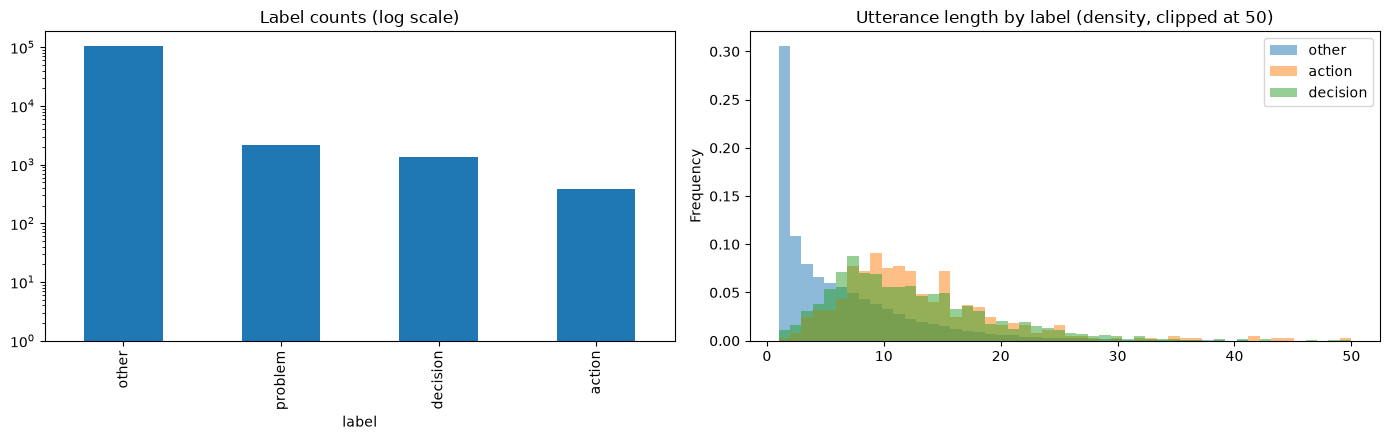

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
df["label"].value_counts().plot.bar(ax=axes[0], log=True)
axes[0].set_title("Label counts (log scale)")

for label in ["other", "action", "decision"]:
    df.loc[df["label"] == label, "n_words"].clip(upper=50).plot.hist(
        bins=50, alpha=0.5, density=True, ax=axes[1], label=label)
axes[1].set_title("Utterance length by label (density, clipped at 50)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Split by session
Steps: derive `session_id`, shuffle sessions with a fixed seed, assign to train/val/test, verify no session appears twice.

In [11]:
df["session_id"] = df["meeting_id"].str[:6]
sessions = sorted(df["session_id"].unique())
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(sessions)

n = len(sessions)
n_train = round(n * SPLIT_FRACTIONS["train"])
n_val = round(n * SPLIT_FRACTIONS["val"])
session_to_split = {}
for i, s in enumerate(sessions):
    session_to_split[s] = "train" if i < n_train else "val" if i < n_train + n_val else "test"

df["split"] = df["session_id"].map(session_to_split)

# Leakage check
split_sessions = {sp: set(df.loc[df["split"] == sp, "session_id"]) for sp in SPLIT_FRACTIONS}
assert not (split_sessions["train"] & split_sessions["val"])
assert not (split_sessions["train"] & split_sessions["test"])
assert not (split_sessions["val"] & split_sessions["test"])
print("No session appears in more than one split.")

summary = pd.crosstab(df["split"], df["label"])
summary["total"] = summary.sum(axis=1)
summary["sessions"] = pd.Series({sp: len(s) for sp, s in split_sessions.items()})
summary["meetings"] = df.groupby("split")["meeting_id"].nunique()
print(summary.loc[["train", "val", "test"]])
print("\nLabel % per split:")
print((pd.crosstab(df["split"], df["label"], normalize="index") * 100).round(2).loc[["train", "val", "test"]])

No session appears in more than one split.
label  action  decision  other  problem  total  sessions  meetings
split                                                             
train     256       932  73080     1604  75872        24        93
val        56       203  14474      298  15031         5        20
test       69       215  16909      252  17445         6        24

Label % per split:
label  action  decision  other  problem
split                                  
train    0.34      1.23  96.32     2.11
val      0.37      1.35  96.29     1.98
test     0.40      1.23  96.93     1.44


## 11. Save
- `ami_labeled.csv`: utterance-level dataset with labels and split
- `ami_abstractive_sentences.csv`: reference summaries (reused in Phases 7 and 8)

In [12]:
columns = ["meeting_id", "session_id", "split", "speaker", "dact_id", "start", "end", "text",
           "n_words", "label", *flag_cols, "da_type"]
labeled_path = PROCESSED_DIR / "ami_labeled.csv"
sentences_path = PROCESSED_DIR / "ami_abstractive_sentences.csv"

df[columns].to_csv(labeled_path, index=False)
sentences.to_csv(sentences_path, index=False)
print("Saved:", labeled_path, df.shape)
print("Saved:", sentences_path, sentences.shape)

Saved: c:\Users\Harijith\Downloads\data\processed\ami_labeled.csv (108348, 16)
Saved: c:\Users\Harijith\Downloads\data\processed\ami_abstractive_sentences.csv (2649, 4)


## 12. Findings summary (paste this back)

In [13]:
print("=== FINDINGS TO REPORT ===")
print("Meetings labelled:", df["meeting_id"].nunique(), "| sessions:", df["session_id"].nunique())
print("Meeting prefixes:", dict(collections.Counter(m[:2] for m in df["meeting_id"].unique())))
print("Rows:", len(df))
print("Label counts:", df["label"].value_counts().to_dict())
print("Multi-linked rows:", int(n_multi), "| orphan links:", orphans, "| unmatched sentence ids:", int(links["summary_type"].isna().sum()))
print("Range pointers:", total_range_pointers)
print("Median words by label:", df.groupby("label")["n_words"].median().to_dict())
print("Split rows:", df["split"].value_counts().to_dict())
print("Test label counts:", df.loc[df["split"] == "test", "label"].value_counts().to_dict())
print("ALSO PASTE: the example utterances from section 8.")

=== FINDINGS TO REPORT ===
Meetings labelled: 137 | sessions: 35
Meeting prefixes: {'ES': 60, 'IS': 38, 'TS': 39}
Rows: 108348
Label counts: {'other': 104463, 'problem': 2154, 'decision': 1350, 'action': 381}
Multi-linked rows: 187 | orphan links: 0 | unmatched sentence ids: 0
Range pointers: 0
Median words by label: {'action': 11.0, 'decision': 11.0, 'other': 4.0, 'problem': 12.0}
Split rows: {'train': 75872, 'test': 17445, 'val': 15031}
Test label counts: {'other': 16909, 'problem': 252, 'decision': 215, 'action': 69}
ALSO PASTE: the example utterances from section 8.
